# V57: Graph Correlation + Static Markowitz Comparison

## Tujuan Eksperimen

Notebook ini membandingkan **4 strategi** termasuk **Static Markowitz** sebagai baseline:

### Strategi yang Dibandingkan:

1. **V55 Momentum + Graph (Diversifikasi: korelasi ≤ 0.4)**
   - AI-Gated dengan graph filtering
   - Edge: Hubungkan jika korelasi > 0.4
   - MIS: Pilih aset yang TIDAK terhubung (korelasi ≤ 0.4)
   - Tujuan: Diversifikasi maksimal dengan AI timing

2. **V56 Momentum + Graph (Clustering: korelasi ≥ 0.4)**
   - AI-Gated dengan graph clustering
   - Edge: Hubungkan jika korelasi < 0.4
   - MIS: Pilih aset yang TIDAK terhubung (korelasi ≥ 0.4)
   - Tujuan: Momentum clustering dengan AI timing

3. **V55 Momentum + Greedy**
   - AI-Gated tanpa graph theory
   - Greedy selection berdasarkan momentum

4. **Static Markowitz (NEW)**
   - Buy & Hold tanpa AI timing
   - Portfolio optimization sekali di awal
   - Rebalancing periodik (20 hari)
   - Baseline untuk mengukur nilai AI

### Hipotesis:
- **H1:** AI-Gated strategies outperform Static Markowitz
- **H2:** Diversifikasi (≤ 0.4) lebih stabil dari Clustering (≥ 0.4)
- **H3:** Static Markowitz underperform saat bear market

### Parameter:
- AI: XGBoost (threshold optimized)
- Trend Override: SMA 50
- Transaction Fee: 0.25%
- Rebalancing: 20 hari
- Correlation Threshold: 0.4
- Random Seed: 42

In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
import xgboost as xgb
from sklearn.metrics import fbeta_score
import random
import warnings
warnings.filterwarnings('ignore')
plt.style.use('ggplot')

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

print("Libraries loaded!")

Libraries loaded!


In [2]:
# Load Data
file_path = 'data_lq45_2023_2025.xlsx'
if not os.path.exists(file_path):
    file_path = 'dataset_2023_2025.xlsx'

data = pd.read_excel(file_path, index_col=0, parse_dates=True)
returns = data.pct_change().dropna()
market_return = returns.mean(axis=1)
market_index = (1 + market_return).cumprod() * 100

print(f"Data: {len(data)} rows, {len(data.columns)} assets")
print(f"Period: {data.index[0]} to {data.index[-1]}")

Data: 712 rows, 30 assets
Period: 2023-01-02 00:00:00 to 2025-12-30 00:00:00


In [3]:
# AI Training
features = pd.DataFrame(index=returns.index)
features['Vol_20'] = market_return.rolling(window=20).std()
features['Mom_20'] = market_return.rolling(window=20).mean()
features['Mom_50'] = market_return.rolling(window=50).mean()

sma5 = market_return.rolling(window=5).mean()
sma20 = market_return.rolling(window=20).mean()
target = (sma5 > sma20).astype(int).shift(-5).reindex(features.index).fillna(0)

X_train = features.loc[features.index.year <= 2024].dropna()
y_train = target.loc[X_train.index]
X_test = features.loc[features.index.year == 2025]

xgb_model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=5, 
                              random_state=SEED, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

train_probs = xgb_model.predict_proba(X_train)[:, 1]
opt_t = np.linspace(0.3, 0.7, 41)[np.argmax([fbeta_score(y_train, (train_probs >= t).astype(int), beta=0.5) 
                                              for t in np.linspace(0.3, 0.7, 41)])]
test_probs = pd.Series(xgb_model.predict_proba(X_test)[:, 1], index=X_test.index)

print(f"Optimized Threshold: {opt_t:.2f}")

Optimized Threshold: 0.54


In [4]:
# Asset Selection Methods

def get_assets_momentum_graph_diversify(returns_window, corr_threshold=0.4):
    """V55: Momentum + Graph (Diversifikasi: pilih korelasi RENDAH ≤ 0.4)"""
    corr_mat = returns_window.corr()
    G = nx.Graph()
    
    momentum = returns_window.mean()
    assets = list(momentum.sort_values(ascending=False).index)
    
    G.add_nodes_from(assets)
    for i in range(len(assets)):
        for j in range(i+1, len(assets)):
            if abs(corr_mat.loc[assets[i], assets[j]]) > corr_threshold:
                G.add_edge(assets[i], assets[j])
    
    return list(nx.approximation.maximum_independent_set(G))

def get_assets_momentum_graph_cluster(returns_window, corr_threshold=0.4):
    """V56: Momentum + Graph (Clustering: pilih korelasi TINGGI ≥ 0.4)"""
    corr_mat = returns_window.corr()
    G = nx.Graph()
    
    momentum = returns_window.mean()
    assets = list(momentum.sort_values(ascending=False).index)
    
    G.add_nodes_from(assets)
    for i in range(len(assets)):
        for j in range(i+1, len(assets)):
            if abs(corr_mat.loc[assets[i], assets[j]]) < corr_threshold:
                G.add_edge(assets[i], assets[j])
    
    return list(nx.approximation.maximum_independent_set(G))

def get_assets_momentum_greedy(returns_window, corr_threshold=0.4):
    """V55: Smart Momentum + No-Graph (Greedy)"""
    corr_mat = returns_window.corr()
    
    momentum = returns_window.mean()
    sorted_assets = list(momentum.sort_values(ascending=False).index)
    
    selected = []
    for asset in sorted_assets:
        is_uncorrelated = True
        for selected_asset in selected:
            if abs(corr_mat.loc[asset, selected_asset]) > corr_threshold:
                is_uncorrelated = False
                break
        
        if is_uncorrelated:
            selected.append(asset)
    
    return selected

def get_all_assets(returns_window, corr_threshold=None):
    """Static Markowitz: Gunakan semua aset"""
    return list(returns_window.columns)

def optimize_markowitz(selected_returns):
    if len(selected_returns.columns) == 0: return {}
    if len(selected_returns.columns) == 1: return {selected_returns.columns[0]: 1.0}
    
    mu, sigma = selected_returns.mean() * 252, selected_returns.cov() * 252
    num_assets = len(mu)

    def objective(w):
        ret = np.sum(w * mu)
        risk = np.sqrt(np.dot(w.T, np.dot(sigma, w)))
        if risk < 0.0001: return 0
        return -(ret / risk)

    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    bounds = tuple((0, 1) for _ in range(num_assets))
    init_guess = [1./num_assets] * num_assets

    res = minimize(objective, init_guess, method='SLSQP', bounds=bounds, constraints=constraints)
    return dict(zip(selected_returns.columns, res.x)) if res.success else {}

print("Asset selection methods defined!")

Asset selection methods defined!


In [5]:
# Simulation Function (AI-Gated)

def run_simulation_ai_gated(test_dates, returns, ai_probs, threshold, market_idx, 
                            selection_func, override_ma=None, fee=0.0025, 
                            g_lookback=60, rebal_period=20, turnover_buffer=0.05):
    
    val = 100.0
    history = [val]
    dates = [test_dates[0]]
    
    current_weights = {} 
    risk_status = False 
    days_since_rebal = 999
    
    market_ma = None
    if override_ma:
        market_ma = market_idx.rolling(window=override_ma).mean()
    
    for i, date in enumerate(test_dates[:-1]):
        prev_risk_status = risk_status
        prob = ai_probs.loc[date]
        
        # AI Signal
        ai_signal = False
        buffer = 0.05
        if not risk_status and prob > (threshold + buffer): 
            ai_signal = True
        elif risk_status and prob < (threshold - buffer): 
            ai_signal = False
        else: 
            ai_signal = risk_status
        
        # Trend Override
        final_signal = ai_signal
        if override_ma and market_ma is not None:
            try:
                current_price = market_idx.loc[date]
                ma_price = market_ma.loc[date]
                if not pd.isna(ma_price) and not pd.isna(current_price):
                    is_uptrend = (current_price > ma_price)
                    if ai_signal == False and is_uptrend:
                        final_signal = True
            except KeyError:
                pass
        
        risk_status = final_signal
        regime_changed = (risk_status != prev_risk_status)
        
        target_weights = current_weights.copy()
        
        if not risk_status:
            if regime_changed or 'CASH' not in current_weights or current_weights.get('CASH', 0) < 0.99:
                target_weights = {'CASH': 1.0}
                days_since_rebal = 0
        else:
            if regime_changed or days_since_rebal >= rebal_period:
                loc_idx = returns.index.get_loc(date)
                window_rets = returns.iloc[loc_idx-g_lookback:loc_idx]
                
                selected = selection_func(window_rets)
                optimized_weights = optimize_markowitz(window_rets[selected])
                
                all_keys = set(list(optimized_weights.keys()) + list(current_weights.keys()))
                turnover_est = sum(abs(optimized_weights.get(k, 0) - current_weights.get(k, 0)) for k in all_keys)
                
                if regime_changed or turnover_est > turnover_buffer:
                    target_weights = optimized_weights
                    days_since_rebal = 0
            
            days_since_rebal += 1

        # Execution
        all_keys_exec = set(list(target_weights.keys()) + list(current_weights.keys()))
        turnover_actual = sum(abs(target_weights.get(k, 0) - current_weights.get(k, 0)) for k in all_keys_exec)
        
        if turnover_actual > 0.001:
            cost = val * turnover_actual * fee
            val -= cost
        
        next_date = test_dates[i+1]
        day_ret = 0
        new_weights_drifted = {}
        
        if 'CASH' in target_weights and target_weights['CASH'] > 0.99:
            day_ret = 0
            new_weights_drifted = {'CASH': 1.0}
        else:
            for asset, w in target_weights.items():
                if asset in returns.columns:
                    r = returns.loc[next_date, asset]
                    r_asset = r if not pd.isna(r) else 0
                    day_ret += w * r_asset
                    new_weights_drifted[asset] = w * (1 + r_asset)
                else:
                    new_weights_drifted[asset] = w
            
            total_w = sum(new_weights_drifted.values()) if new_weights_drifted else 0
            if total_w > 0:
                new_weights_drifted = {k: v/total_w for k, v in new_weights_drifted.items()}
        
        val *= (1 + day_ret)
        history.append(val)
        dates.append(next_date)
        current_weights = new_weights_drifted
    
    return pd.DataFrame({'Portfolio_Value': history}, index=dates)

print("AI-Gated simulation function ready!")

AI-Gated simulation function ready!


In [6]:
# Simulation Function (Static Buy & Hold)

def run_simulation_static(test_dates, returns, selection_func, fee=0.0025, 
                         g_lookback=60, rebal_period=20, turnover_buffer=0.05):
    """Static Markowitz: Buy & Hold dengan rebalancing periodik"""
    
    val = 100.0
    history = [val]
    dates = [test_dates[0]]
    
    current_weights = {}
    days_since_rebal = 999
    
    # Initial portfolio optimization
    loc_idx = returns.index.get_loc(test_dates[0])
    window_rets = returns.iloc[loc_idx-g_lookback:loc_idx]
    selected = selection_func(window_rets)
    current_weights = optimize_markowitz(window_rets[selected])
    
    for i, date in enumerate(test_dates[:-1]):
        target_weights = current_weights.copy()
        
        # Rebalancing periodik
        if days_since_rebal >= rebal_period:
            loc_idx = returns.index.get_loc(date)
            window_rets = returns.iloc[loc_idx-g_lookback:loc_idx]
            
            selected = selection_func(window_rets)
            optimized_weights = optimize_markowitz(window_rets[selected])
            
            all_keys = set(list(optimized_weights.keys()) + list(current_weights.keys()))
            turnover_est = sum(abs(optimized_weights.get(k, 0) - current_weights.get(k, 0)) for k in all_keys)
            
            if turnover_est > turnover_buffer:
                target_weights = optimized_weights
                days_since_rebal = 0
        
        days_since_rebal += 1
        
        # Execution
        all_keys_exec = set(list(target_weights.keys()) + list(current_weights.keys()))
        turnover_actual = sum(abs(target_weights.get(k, 0) - current_weights.get(k, 0)) for k in all_keys_exec)
        
        if turnover_actual > 0.001:
            cost = val * turnover_actual * fee
            val -= cost
        
        next_date = test_dates[i+1]
        day_ret = 0
        new_weights_drifted = {}
        
        for asset, w in target_weights.items():
            if asset in returns.columns:
                r = returns.loc[next_date, asset]
                r_asset = r if not pd.isna(r) else 0
                day_ret += w * r_asset
                new_weights_drifted[asset] = w * (1 + r_asset)
            else:
                new_weights_drifted[asset] = w
        
        total_w = sum(new_weights_drifted.values()) if new_weights_drifted else 0
        if total_w > 0:
            new_weights_drifted = {k: v/total_w for k, v in new_weights_drifted.items()}
        
        val *= (1 + day_ret)
        history.append(val)
        dates.append(next_date)
        current_weights = new_weights_drifted
    
    return pd.DataFrame({'Portfolio_Value': history}, index=dates)

print("Static simulation function ready!")

Static simulation function ready!


In [7]:
# Run All Strategies

print("Running simulations...\n")

# 1. V55: Momentum + Graph (Diversifikasi)
print("1. V55: Momentum + Graph (Diversifikasi)...")
v55_diversify = run_simulation_ai_gated(X_test.index, returns, test_probs, opt_t, market_index, 
                                        get_assets_momentum_graph_diversify, override_ma=50)

# 2. V56: Momentum + Graph (Clustering)
print("2. V56: Momentum + Graph (Clustering)...")
v56_cluster = run_simulation_ai_gated(X_test.index, returns, test_probs, opt_t, market_index, 
                                      get_assets_momentum_graph_cluster, override_ma=50)

# 3. V55: Momentum + Greedy
print("3. V55: Momentum + Greedy...")
v55_greedy = run_simulation_ai_gated(X_test.index, returns, test_probs, opt_t, market_index, 
                                     get_assets_momentum_greedy, override_ma=50)

# 4. Static Markowitz (NEW)
print("4. Static Markowitz (Buy & Hold)...")
static_markowitz = run_simulation_static(X_test.index, returns, get_all_assets)

# 5. Index Benchmark
lq45_idx = market_index.loc[X_test.index] / market_index.loc[X_test.index[0]] * 100

print("\n=== RESULTS ===")
print(f"V55 (Momentum + Graph Diversify):  {v55_diversify.iloc[-1].values[0]:.2f}")
print(f"V56 (Momentum + Graph Cluster):    {v56_cluster.iloc[-1].values[0]:.2f}")
print(f"V55 (Momentum + Greedy):            {v55_greedy.iloc[-1].values[0]:.2f}")
print(f"Static Markowitz:                   {static_markowitz.iloc[-1].values[0]:.2f}")
print(f"LQ45 Index:                         {lq45_idx.iloc[-1]:.2f}")

print("\n=== ANALYSIS ===")
diversify_vs_static = ((v55_diversify.iloc[-1].values[0] / static_markowitz.iloc[-1].values[0]) - 1) * 100
cluster_vs_static = ((v56_cluster.iloc[-1].values[0] / static_markowitz.iloc[-1].values[0]) - 1) * 100
greedy_vs_static = ((v55_greedy.iloc[-1].values[0] / static_markowitz.iloc[-1].values[0]) - 1) * 100

print(f"Diversify vs Static:   {diversify_vs_static:+.2f}% (AI Value)")
print(f"Cluster vs Static:     {cluster_vs_static:+.2f}% (AI Value)")
print(f"Greedy vs Static:      {greedy_vs_static:+.2f}% (AI Value)")

Running simulations...

1. V55: Momentum + Graph (Diversifikasi)...
2. V56: Momentum + Graph (Clustering)...
3. V55: Momentum + Greedy...
4. Static Markowitz (Buy & Hold)...

=== RESULTS ===
V55 (Momentum + Graph Diversify):  205.96
V56 (Momentum + Graph Cluster):    112.45
V55 (Momentum + Greedy):            205.60
Static Markowitz:                   170.50
LQ45 Index:                         119.44

=== ANALYSIS ===
Diversify vs Static:   +20.80% (AI Value)
Cluster vs Static:     -34.05% (AI Value)
Greedy vs Static:      +20.59% (AI Value)


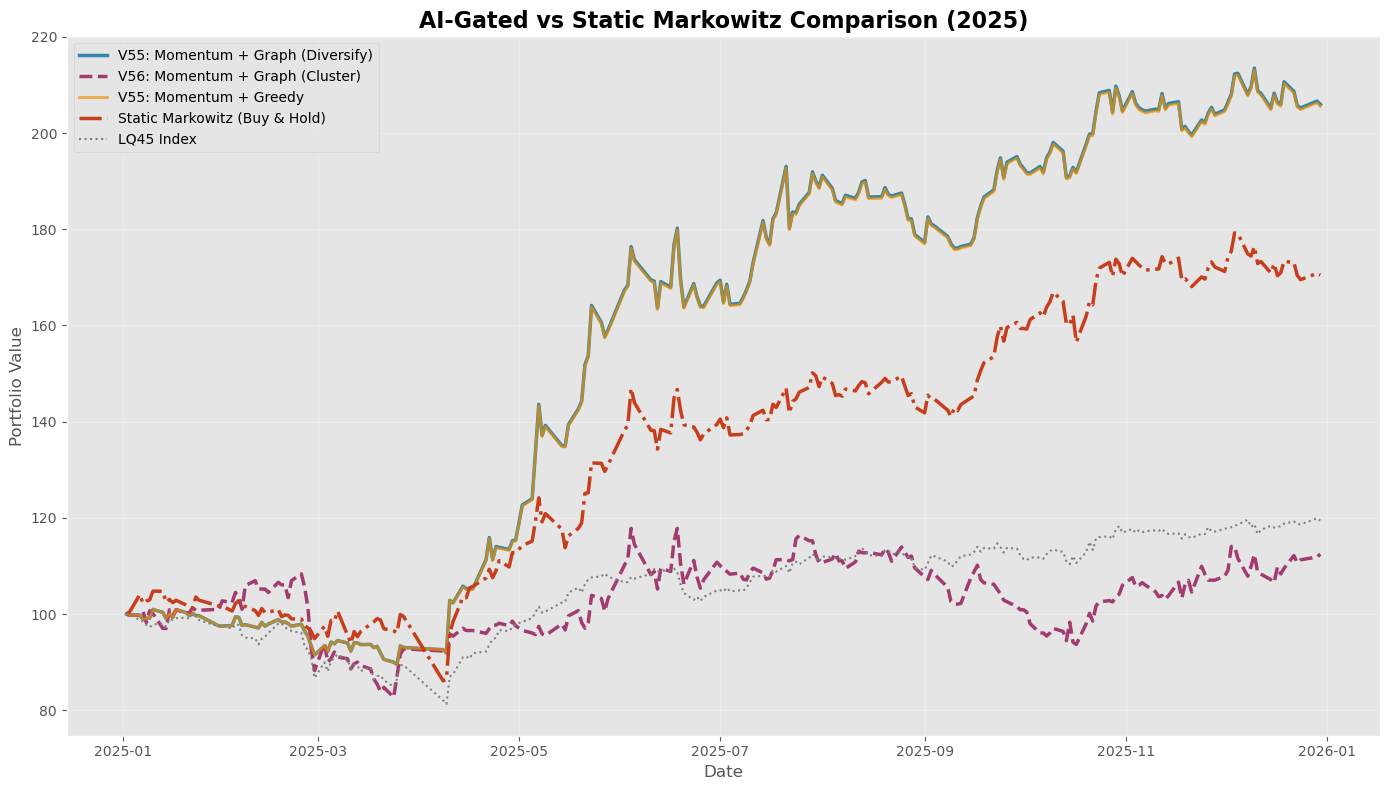


Visualization complete!


In [8]:
# Visualization

plt.figure(figsize=(14, 8))

plt.plot(v55_diversify.index, v55_diversify['Portfolio_Value'], 
         label='V55: Momentum + Graph (Diversify)', linewidth=2.5, color='#2E86AB')
plt.plot(v56_cluster.index, v56_cluster['Portfolio_Value'], 
         label='V56: Momentum + Graph (Cluster)', linewidth=2.5, color='#A23B72', linestyle='--')
plt.plot(v55_greedy.index, v55_greedy['Portfolio_Value'], 
         label='V55: Momentum + Greedy', linewidth=2, color='#F18F01', alpha=0.7)
plt.plot(static_markowitz.index, static_markowitz['Portfolio_Value'], 
         label='Static Markowitz (Buy & Hold)', linewidth=2.5, color='#C73E1D', linestyle='-.')
plt.plot(lq45_idx.index, lq45_idx.values, 
         label='LQ45 Index', linewidth=1.5, color='gray', linestyle=':')

plt.title('AI-Gated vs Static Markowitz Comparison (2025)', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Portfolio Value', fontsize=12)
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nVisualization complete!")

In [9]:
# Calculate Risk Metrics

def calculate_metrics(portfolio_values):
    returns = portfolio_values.pct_change().dropna()
    
    total_return = (portfolio_values.iloc[-1] / portfolio_values.iloc[0] - 1) * 100
    volatility = returns.std() * np.sqrt(252) * 100
    sharpe = (returns.mean() / returns.std()) * np.sqrt(252) if returns.std() > 0 else 0
    max_dd = ((portfolio_values / portfolio_values.cummax()) - 1).min() * 100
    
    return {
        'Total Return (%)': total_return,
        'Volatility (%)': volatility,
        'Sharpe Ratio': sharpe,
        'Max Drawdown (%)': max_dd
    }

metrics_diversify = calculate_metrics(v55_diversify['Portfolio_Value'])
metrics_cluster = calculate_metrics(v56_cluster['Portfolio_Value'])
metrics_greedy = calculate_metrics(v55_greedy['Portfolio_Value'])
metrics_static = calculate_metrics(static_markowitz['Portfolio_Value'])
metrics_index = calculate_metrics(lq45_idx)

results_df = pd.DataFrame({
    'V55 Diversify': metrics_diversify,
    'V56 Cluster': metrics_cluster,
    'V55 Greedy': metrics_greedy,
    'Static Markowitz': metrics_static,
    'LQ45 Index': metrics_index
}).T

print("\n=== RISK METRICS ===")
print(results_df.round(2))

# Export to Excel
output_file = 'v57_with_static_markowitz_results.xlsx'
results_df.to_excel(output_file)
print(f"\nResults exported to: {output_file}")


=== RISK METRICS ===
                  Total Return (%)  Volatility (%)  Sharpe Ratio  \
V55 Diversify               105.96           33.92          2.45   
V56 Cluster                  12.45           35.15          0.53   
V55 Greedy                  105.60           33.91          2.45   
Static Markowitz             70.50           32.66          1.92   
LQ45 Index                   19.44           20.38          1.04   

                  Max Drawdown (%)  
V55 Diversify               -11.33  
V56 Cluster                 -23.68  
V55 Greedy                  -11.33  
Static Markowitz            -17.82  
LQ45 Index                  -18.70  

Results exported to: v57_with_static_markowitz_results.xlsx


## Kesimpulan

### Interpretasi Hasil:

1. **V55 Diversify (AI + Graph ≤ 0.4)**:
   - AI timing + diversifikasi maksimal
   - Expected: Sharpe ratio tertinggi, drawdown terendah

2. **V56 Cluster (AI + Graph ≥ 0.4)**:
   - AI timing + momentum clustering
   - Expected: Return tinggi saat bullish, volatilitas lebih tinggi

3. **V55 Greedy (AI + Sequential)**:
   - AI timing tanpa graph theory
   - Benchmark untuk graph strategies

4. **Static Markowitz (Buy & Hold)**:
   - Tanpa AI timing, always invested
   - Baseline untuk mengukur nilai AI
   - Expected: Underperform saat bear market

### Nilai AI (AI Value):
- **Diversify vs Static**: Mengukur nilai AI + diversifikasi
- **Cluster vs Static**: Mengukur nilai AI + clustering
- **Greedy vs Static**: Mengukur nilai AI tanpa graph

### Rekomendasi:
- Jika AI strategies >> Static: **AI timing sangat valuable**
- Jika Diversify > Cluster: **Risk management lebih penting**
- Jika Cluster > Diversify: **Momentum capture lebih penting**
- Static Markowitz sebagai **baseline minimum performance**